# Predicting the pollution grade (A–E) and its consequences on the individual taxation 

## Model selection and comparison

In [31]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier,RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


### Data Cleaning 

Currently, electric cars are not taxed in France. Let's check what do electric cars bcan bring to the model and if we should keep them or not. 



In [32]:
df = pd.read_csv('df_model_0608.csv', low_memory=False)

df.head()

,_id_fr,model_utac,commercial_name,ntic,hybrid,power_admin,power_max_kw,transmission,cons_urb_l100km,cons_extraurb_l100km,...,tvv_comp,model_comp,kw_delta,co2_delta,kg_delta,tv_comp,match_steps,r_merged,n_eu_records,n_fr_configs
0,0.0,159,159 1750 Tbi (200ch),M10ALFVP000G340,non,12.0,147.0,M 6,11.3,5.8,...,939AXN1B52C,159,0,0.0,0,939AXN1B,Step 1: Exact TVV (T+Va+Ve),1.0,1,1
1,3.0,159,159 2.0 JTDm (136ch),M10ALFVP000F303,non,7.0,100.0,M 6,6.6,4.2,...,939AXR1B64B,159,0,0.0,0,939AXR1B,Step 1: Exact TVV (T+Va+Ve),9.0,5,1
2,9.0,159,159 SW 2.0 JTDm (136ch),M10ALFVP000J307,non,7.0,100.0,M 6,6.8,4.3,...,939BXR1B65B,159,0,0.0,0,939BXR1B,Step 1: Exact TVV (T+Va+Ve),2.0,2,1
3,10.0,159,159 SW 2.0 JTDm (170ch),M10ALFVP000K308,non,9.0,125.0,M 6,7.1,4.4,...,939BXS1B67,159,0,0.0,10,939BXS1B,Step 1: Exact TVV (T+Va+Ve),6.0,2,1
4,22.0,GIULIETTA,GIULIETTA 1.4 T-jet (120ch) S/S,M10ALFVP000Y322,non,7.0,88.0,M 6,8.4,5.3,...,940FXA1A00B,GIULIETTA,0,0.0,0,940FXA1A,Step 1: Exact TVV (T+Va+Ve),626.0,42,3


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   _id_fr                  3660 non-null   float64
 1   model_utac              3660 non-null   object 
 2   commercial_name         3660 non-null   object 
 3   ntic                    3660 non-null   object 
 4   hybrid                  3660 non-null   object 
 5   power_admin             3660 non-null   float64
 6   power_max_kw            3660 non-null   float64
 7   transmission            3660 non-null   object 
 8   cons_urb_l100km         3638 non-null   float64
 9   cons_extraurb_l100km    3638 non-null   float64
 10  cons_mix_l100km         3641 non-null   float64
 11  co2_g_km                3641 non-null   float64
 12  co_g_km                 3635 non-null   float64
 13  hc_g_km                 1527 non-null   float64
 14  nox_g_km                3635 non-null   

In [34]:
df=df.rename(columns={"mkerb_weight_max_kg":"kerb_weight_max_kg"})

# Drop empty columns 
df=df.drop(columns=['z (Wh/km)','date_maj'])

# Drop duplicates 
df = df.drop_duplicates().reset_index(drop=True)

# Created Boolean 
df['hybrid'] = df['hybrid'].map({'oui': True, 'non': False})

# Modificate columns types 
num_candidates = ['power_admin', 'power_max_kw', 'cons_urb_l100km',
                  'cons_extraurb_l100km', 'cons_mix_l100km']

df[num_candidates] = df[num_candidates].apply(pd.to_numeric, errors='coerce')

# Categorize electric cars 
df['is_electric'] = (df['fuel_comp'] == 'EL') | (df['co2_comp'] == 0)

#Remove spaces at the beggining/ end of each value 
for c in ['brand_group', 'model_comp', 'fuel_comp']:
    if c in df.columns:
        df[c] = df[c].str.strip()


In [35]:
# Focus on electric cars

electric_cars= df[df['is_electric']]
print(f"Count of electric cars : {len(electric_cars)}")

print("CO2 (co2_comp) :")
print(electric_cars['co2_comp'].describe())
print("\nUnique values :", electric_cars['co2_comp'].unique())
print("VMissing values :", electric_cars['co2_comp'].isna().sum())

print("\nNOx (nox_g_km) :")
print(f"Entered values : {electric_cars['nox_g_km'].notna().sum()} / {len(electric_cars)}")
print(f"Missing values : {electric_cars['nox_g_km'].isna().sum()} / {len(electric_cars)}")

print("\nDistribution by fuel type :")
print(electric_cars['fuel_comp'].value_counts(dropna=False))

print("\nDistribution by body type:")
print(electric_cars['body_type_grp'].value_counts(dropna=False))

(electric_cars[['brand_group', 'model_comp', 'co2_comp', 'nox_g_km']].drop_duplicates(subset='model_comp').head(15))

Count of electric cars : 19
CO2 (co2_comp) :
count    19.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: co2_comp, dtype: float64

Unique values : [0.]
VMissing values : 0

NOx (nox_g_km) :
Entered values : 0 / 19
Missing values : 19 / 19

Distribution by fuel type :
fuel_comp
EL    19
Name: count, dtype: int64

Distribution by body type:
body_type_grp
Van / MPV            9
Sedan / Hatchback    5
Sport / Special      5
Name: count, dtype: int64


,brand_group,model_comp,co2_comp,nox_g_km
571,CITROEN,C ZERO,0.0,NaN
2005,MIA,NON RENSEIGN,0.0,NaN
2006,MIA,NaN,0.0,NaN
2089,MITSUBISHI,I MIEV,0.0,NaN
2121,NISSAN,LEAF,0.0,NaN
2548,PEUGEOT,ION,0.0,NaN
2776,SMART,FORTWO,0.0,NaN
2828,TESLA,ROADSTER,0.0,NaN
3286,RENAULT,FLUENCE Z E,0.0,NaN
3389,RENAULT,ZOE,0.0,NaN


Conclusion : No emission at all from electric cars (Phev mostly)

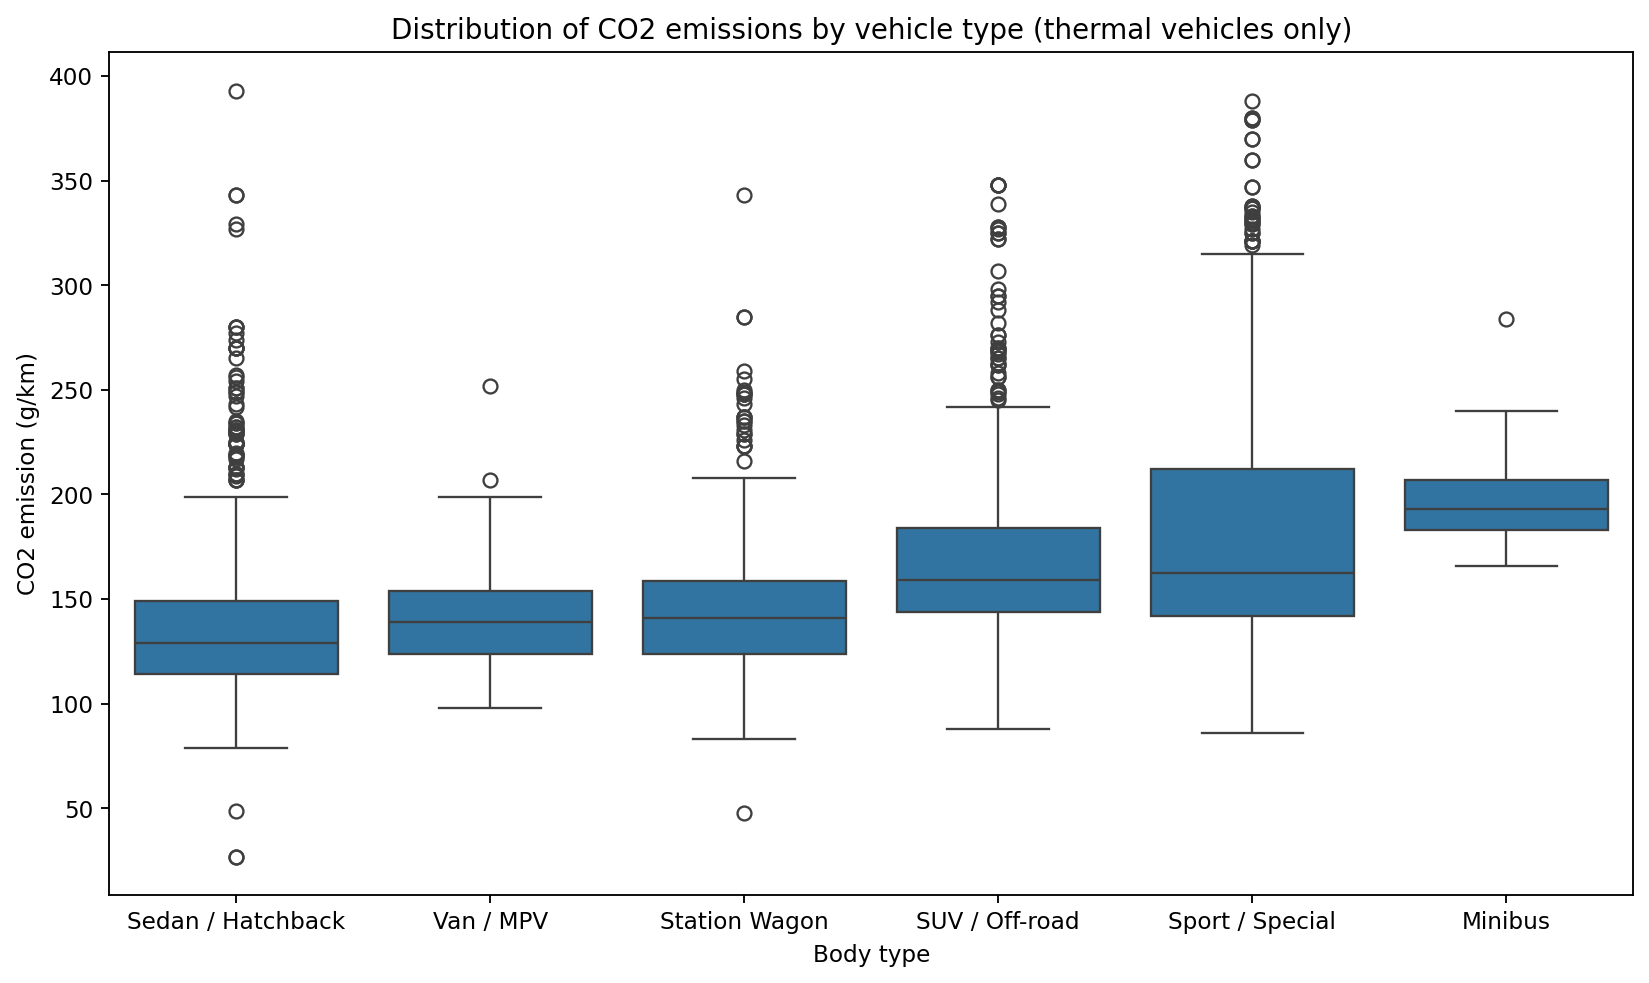

In [36]:
# New DataFrame : Thermic cars only 

df_therm = df[~df['is_electric']]

order = df_therm.groupby('body_type_grp')['co2_comp'].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_therm, x='body_type_grp', y='co2_comp', order=order, ax=ax)
ax.set_title('Distribution of CO2 emissions by vehicle type (thermal vehicles only)')
ax.set_xlabel('Body type')
ax.set_ylabel('CO2 emission (g/km)')
plt.tight_layout()
plt.show()

In [37]:
df_therm = df[~df['is_electric']].copy()

bins = [0, 1250, 1500, 1750, 2000, 2250, 2500, np.inf]
labels = ['<1250', '1250-1500', '1500-1750', '1750-2000','2000-2250', '2250-2500', '>2500']
df_therm['weight_class'] = pd.cut(df_therm['kerb_weight_min_kg'], bins=bins, labels=labels)

ct_co2 = pd.crosstab(df_therm['weight_class'],
                     df_therm['fuel_grp'],
                     values=df_therm['co2_comp'],
                     aggfunc='mean').round(1)
ct_co2

fuel_grp,Diesel,E85,Electric/Hybrid,Gas(-Mix),Petrol
weight_class,,,,,
<1250,101.1,NaN,101.4,109.7,123.0
1250-1500,120.0,109.5,91.8,140.1,148.7
1500-1750,138.7,27.0,102.1,151.8,184.9
1750-2000,158.8,NaN,136.6,48.0,225.4
2000-2250,193.3,NaN,157.8,NaN,247.1
2250-2500,210.7,246.0,197.0,NaN,309.6
>2500,233.8,NaN,256.0,NaN,332.0


In [38]:
ct_nox = pd.crosstab(df_therm['weight_class'],
                     df_therm['fuel_grp'],
                     values=df_therm['nox_g_km'],
                     aggfunc='mean').round(3)
ct_nox

fuel_grp,Diesel,E85,Electric/Hybrid,Gas(-Mix),Petrol
weight_class,,,,,
<1250,0.140,NaN,0.009,0.029,0.021
1250-1500,0.142,0.010,0.006,0.026,0.024
1500-1750,0.141,0.001,0.078,0.016,0.023
1750-2000,0.148,NaN,0.066,0.036,0.028
2000-2250,0.198,NaN,0.015,NaN,0.026
2250-2500,0.207,0.023,0.024,NaN,0.033
>2500,0.684,NaN,0.006,NaN,0.034


In [39]:
print(df_therm.groupby('weight_class', observed=True)[['co2_comp', 'nox_g_km']].mean())

                co2_comp  nox_g_km
weight_class                      
<1250         116.824663  0.051243
1250-1500     133.889376  0.081406
1500-1750     151.662479  0.106009
1750-2000     176.707792  0.110329
2000-2250     203.400709  0.159218
2250-2500     239.705882  0.145368
>2500         277.920000  0.357923


In [40]:
# Cleaning: weight 

weight = df_therm[['kerb_weight_min_kg', 'kerb_weight_max_kg']].dropna().copy()
weight.columns = ['weight_min', 'weight_max']
weight['spread'] = weight['weight_max'] - weight['weight_min']

print(weight['spread'].describe())
print("min == max :", (weight['spread'] == 0).sum())
print("Anomalies min > max :", (weight['spread'] < 0).sum())

df_therm['kerb_weight_mean_kg'] = (df_therm['kerb_weight_min_kg']
                                   + df_therm['kerb_weight_max_kg']) / 2

bins = [0, 1000, 1500, 2000, 2500, np.inf]
labels = ['<1000', '1000-1500', '1500-2000', '2000-2500', '>2500']
df_therm['weight_range'] = pd.cut(df_therm['kerb_weight_mean_kg'], bins=bins, labels=labels)

count    3641.000000
mean       20.120571
std        46.769414
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       273.000000
Name: spread, dtype: float64
min == max : 2907
Anomalies min > max : 0


We restrict the analysis to vehicles with a combustion engine, since fully electric cars emit nothing at the tailpipe and are exempt from the French penalty scheme anyway.

Following the logic of the Crit'Air sticker system used in French cities, we classify these vehicles not only by how much they contribute to climate change, but also by how harmful they are to public health. No such label exists in the source data, so we add it in two steps: a continuous pollution score combining the three available emission measurements, and a discrete pollution grade (A to E) derived from it.

pollution_score is the weighted percentile-rank composite (CO2 50%, NOx 30%, PM 20%) and pollution_grade its quintile discretisation. Weights are renormalised over the
components actually available for each vehicle, so that a missing NOx or PM measurement does not silently pull the score down.

# Modelling — predicting the pollution grade (A–E)

## Step 1 — Building the target

pollution_score is a weighted combination of the three emission measurements. Each pollutant is converted into a percentile rank (a value between 0 and 1 giving the vehicle's position within the fleet),which puts the three on a common scale and is robust to outliers.

The weights — CO2 50%, NOx 30%, PM 20% — are our own choice

pollution_grade is the quintile discretisation of the score into five labels, A (cleanest) to E (most polluting), in the spirit of the Crit'Air and DPE labels.

In [41]:
WEIGHTS = {'co2_comp': 0.5, 'nox_g_km': 0.3, 'pm_g_km': 0.2}

ranks = pd.DataFrame(index=df_therm.index)
for col in WEIGHTS:
    ranks[col] = df_therm[col].rank(pct=True)

# Effective weight of each pollutant, set to 0 where the measurement is missing
w_eff = pd.DataFrame({col: ranks[col].notna() * wt for col, wt in WEIGHTS.items()})
df_therm['pollution_score'] = (ranks.fillna(0) * w_eff).sum(axis=1) / w_eff.sum(axis=1) * 100

df_therm['pollution_grade'], grade_bins = pd.qcut(
    df_therm['pollution_score'], 5,
    labels=['A', 'B', 'C', 'D', 'E'], retbins=True)

print(f"Vehicles: {len(df_therm):,}")
print(df_therm['pollution_grade'].value_counts().sort_index())

Vehicles: 3,641
pollution_grade
A    729
B    728
C    728
D    728
E    728
Name: count, dtype: int64


## Step 2 — Defining X and y


We remove power_admin from the feature set. It is not a technical characteristic of the vehicle but an administrative one, derived from theemissions we are trying to predict: it is defined as PA = (CO2 emission / 45) + (Engine Power / 40)^1.6 (where CO2 emission is in g/km and the engine power in kW)

In [42]:

FEATURES_NUM = ["power_max_kw", "kerb_weight_min_kg", "ec (cm3)","w (mm)","at1 (mm)", "at2 (mm)"]
FEATURES_CAT = ["fuel_grp", "transmission", "segment_grp", "body_type_grp","hybrid"]

In [43]:
X = df_therm[FEATURES_NUM + FEATURES_CAT].copy()

# hybrid was mapped to True/False during cleaning -> back to text for the dummies
X['hybrid'] = X['hybrid'].map({True: 'yes', False: 'no'})

# Missing values: median for numbers, a dedicated category for text
for col in FEATURES_NUM:
    X[col] = X[col].fillna(X[col].median())
for col in FEATURES_CAT:
    X[col] = X[col].fillna('Unknown')

# Categorical variables -> dummy columns
X = pd.get_dummies(X, columns=FEATURES_CAT)

y = df_therm['pollution_grade'].astype(str)

print("X:", X.shape, "and y:", y.shape)

X: (3641, 37) and y: (3641,)


## Step 3 — Train/test split

80% training, 20% test +  random_state=42


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

Train: 2,912 rows | Test: 729 rows


## Step 4 — Training the models

One block per model, all on the same split. Trees use the raw data, distance- and
scale-sensitive models use the scaled version.

In [45]:
# --- Logistic regression (baseline) ---
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("Logistic regression:", round(accuracy_score(y_test, y_pred_logreg), 3))

Logistic regression: 0.58


In [46]:
# --- KNN ---
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)          # scaling essential: KNN uses distances
y_pred_knn = knn.predict(X_test_scaled)

print("KNN (k=15):", round(accuracy_score(y_test, y_pred_knn), 3))

KNN (k=15): 0.55


In [47]:
# --- Decision Tree ---
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)                # no scaling needed for trees
y_pred_tree = tree.predict(X_test)

print("Decision Tree:", round(accuracy_score(y_test, y_pred_tree), 3))
print("  depth:", tree.get_depth(), "and leaves:", tree.get_n_leaves())
print("  accuracy on the training set:",
      round(accuracy_score(y_train, tree.predict(X_train)), 3))

Decision Tree: 0.695
  depth: 24 and leaves: 833
  accuracy on the training set: 0.971


In [48]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest:", round(accuracy_score(y_test, y_pred_rf), 3))

Random Forest: 0.782


In [49]:
# --- Histogram Gradient Boosting ---
gb = HistGradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Hist Gradient Boosting:", round(accuracy_score(y_test, y_pred_gb), 3))

Hist Gradient Boosting: 0.781


## Step 5 — Score prediction




In [50]:
score = df_therm['pollution_score']
score_train = score.loc[X_train.index]
score_test = score.loc[X_test.index]

reg = RandomForestRegressor(n_estimators=200, random_state=42)
reg.fit(X_train, score_train)
score_pred = reg.predict(X_test)

print("R² on the continuous score:", round(r2_score(score_test, score_pred), 3))

# Continuous score -> grades, using the exact same quintile cut points as y
bins = grade_bins.copy()
bins[0], bins[-1] = -np.inf, np.inf   # so no prediction falls outside the range

y_pred_reg = pd.cut(score_pred, bins=bins,
                    labels=['A', 'B', 'C', 'D', 'E']).astype(str)

print("Accuracy after mapping to grades:",
      round(accuracy_score(y_test, y_pred_reg), 3))


R² on the continuous score: 0.902
Accuracy after mapping to grades: 0.738


## Step 6 — Comparing the results

We compare the models on accuracy and macro F1-score. 

In [51]:
results_df = pd.DataFrame({
    'accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_reg),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
    ],
    'f1_macro': [
        f1_score(y_test, y_pred_logreg, average='macro'),
        f1_score(y_test, y_pred_knn, average='macro'),
        f1_score(y_test, y_pred_reg, average='macro'),
        f1_score(y_test, y_pred_gb, average='macro'),
        f1_score(y_test, y_pred_tree, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
    ],
}, index=['Logistic Regression', 'KNN (k=15)', 'RF Regression -> grades',
          'Hist Gradient Boosting', 'Decision Tree', 'Random Forest'])

results_df.round(3)

,accuracy,f1_macro
Logistic Regression,0.580,0.582
KNN (k=15),0.550,0.550
RF Regression -> grades,0.738,0.741
Hist Gradient Boosting,0.781,0.780
Decision Tree,0.695,0.693
Random Forest,0.782,0.781


In [52]:
results_df = pd.DataFrame({
    'accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
    ],
    'f1_macro': [
        f1_score(y_test, y_pred_logreg, average='macro'),
        f1_score(y_test, y_pred_knn, average='macro'),
        f1_score(y_test, y_pred_gb, average='macro'),
        f1_score(y_test, y_pred_tree, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
    ],
}, index=['Logistic Regression', 'KNN (k=15)', 'Hist Gradient Boosting', 'Decision Tree', 'Random Forest'])

results_df.round(3)

,accuracy,f1_macro
Logistic Regression,0.580,0.582
KNN (k=15),0.550,0.550
Hist Gradient Boosting,0.781,0.780
Decision Tree,0.695,0.693
Random Forest,0.782,0.781


In [53]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           A       0.84      0.90      0.87       146
           B       0.72      0.71      0.71       146
           C       0.68      0.70      0.69       145
           D       0.77      0.73      0.75       146
           E       0.89      0.86      0.87       146

    accuracy                           0.78       729
   macro avg       0.78      0.78      0.78       729
weighted avg       0.78      0.78      0.78       729



In [66]:
# Cross-validation: Logistic Regression (on scaled data)
cv_logreg = cross_val_score(LogisticRegression(max_iter=1000),
                            X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Accuracy on each fold:", cv_logreg.round(3))
print("Mean:", round(cv_logreg.mean(), 3))
print("Standard deviation:", round(cv_logreg.std(), 3))

Accuracy on each fold: [0.54  0.516 0.548 0.565 0.552]
Mean: 0.544
Standard deviation: 0.016


In [67]:
# Cross-validation: KNN (on scaled data)
cv_knn = cross_val_score(KNeighborsClassifier(n_neighbors=15),
                         X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Accuracy on each fold:", cv_knn.round(3))
print("Mean:", round(cv_knn.mean(), 3))
print("Standard deviation:", round(cv_knn.std(), 3))

Accuracy on each fold: [0.53  0.509 0.526 0.521 0.548]
Mean: 0.527
Standard deviation: 0.013


In [68]:
# Cross-validation: Decision Tree
cv_tree = cross_val_score(DecisionTreeClassifier(random_state=42),
                          X_train, y_train, cv=5, scoring='accuracy')

print("Accuracy on each fold:", cv_tree.round(3))
print("Mean:", round(cv_tree.mean(), 3))
print("Standard deviation:", round(cv_tree.std(), 3))

Accuracy on each fold: [0.674 0.691 0.684 0.662 0.655]
Mean: 0.673
Standard deviation: 0.014


In [72]:
cv_rf = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42),X_train, y_train, cv=5, scoring='accuracy')

print("Accuracy on each fold:", cv_scores.round(3))
print("Mean:", round(cv_scores.mean(), 3))
print("Standard deviation:", round(cv_scores.std(), 3))

Accuracy on each fold: [0.744 0.763 0.737 0.713 0.723]
Mean: 0.736
Standard deviation: 0.017


In [69]:
# Cross-validation: Hist Gradient Boosting
cv_gb = cross_val_score(HistGradientBoostingClassifier(random_state=42),
                        X_train, y_train, cv=5, scoring='accuracy')

print("Accuracy on each fold:", cv_gb.round(3))
print("Mean:", round(cv_gb.mean(), 3))
print("Standard deviation:", round(cv_gb.std(), 3))

Accuracy on each fold: [0.748 0.748 0.744 0.701 0.727]
Mean: 0.734
Standard deviation: 0.018


In [73]:
results_df['cv_mean'] = [cv_logreg.mean(), cv_knn.mean(), cv_gb.mean(), cv_tree.mean(), cv_rf.mean()]
results_df['cv_std'] = [cv_logreg.std(), cv_knn.std(), cv_gb.std(), cv_tree.std(), cv_rf.std()]
print(results_df.round(3))

                        accuracy  f1_macro  cv_mean  cv_std
Logistic Regression        0.580     0.582    0.544   0.016
KNN (k=15)                 0.550     0.550    0.527   0.013
Hist Gradient Boosting     0.781     0.780    0.734   0.018
Decision Tree              0.695     0.693    0.673   0.014
Random Forest              0.782     0.781    0.736   0.017


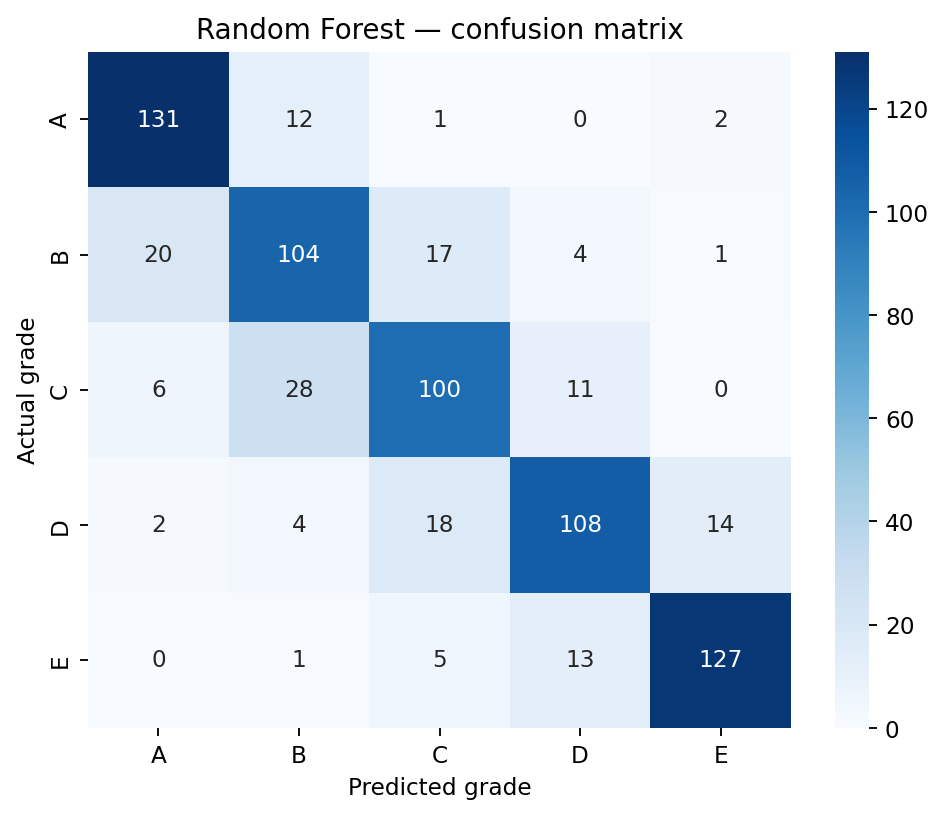

In [55]:
# Confusion matrix

labels = ['A', 'B', 'C', 'D', 'E']
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Random Forest — confusion matrix')
ax.set_xlabel('Predicted grade')
ax.set_ylabel('Actual grade')
plt.tight_layout()
plt.show()

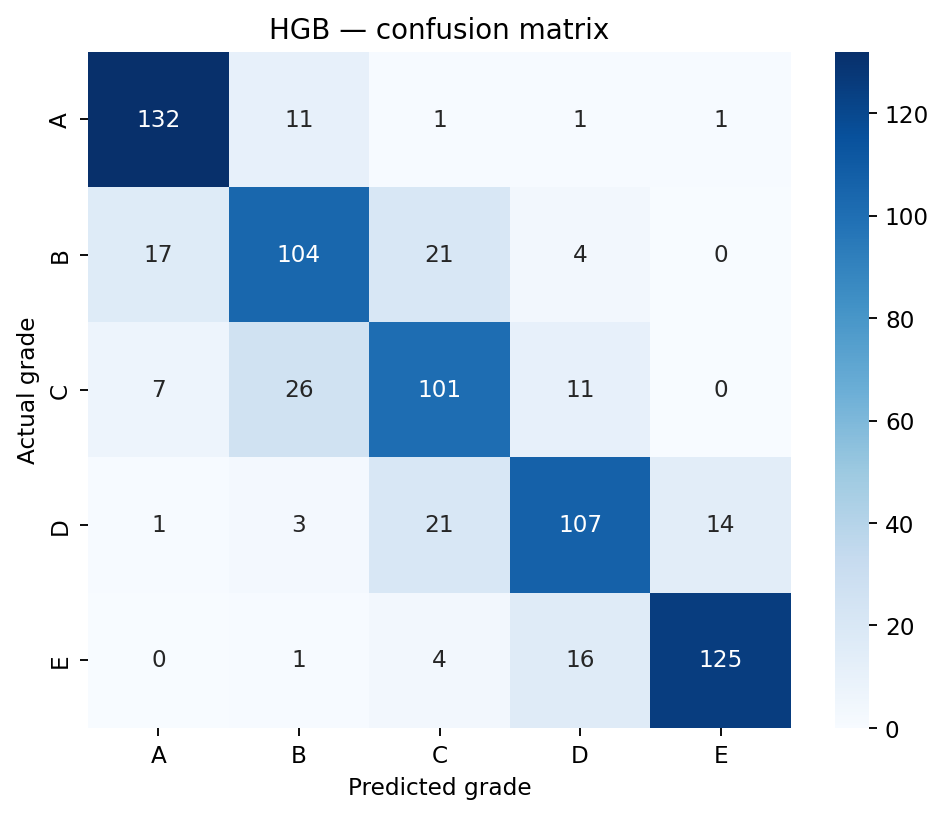

In [56]:
# Confusion matrix

labels = ['A', 'B', 'C', 'D', 'E']
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('HGB — confusion matrix')
ax.set_xlabel('Predicted grade')
ax.set_ylabel('Actual grade')
plt.tight_layout()
plt.show()

In [57]:
labels = ['A', 'B', 'C', 'D', 'E']
correct = adjacent = severe = 0

for i in range(5):
    for j in range(5):
        distance = abs(i - j)
        if distance == 0:
            correct += cm_rf[i, j]
        elif distance == 1:
            adjacent += cm_rf[i, j]
        else:
            severe += cm_rf[i, j]

total = cm_rf.sum()
print(f"Exact              : {correct} ({correct / total:.1%})")
print(f"Off by one grade   : {adjacent} ({adjacent / total:.1%})")
print(f"Off by two or more : {severe} ({severe / total:.1%})")
print(f"Correct within one grade : {(correct + adjacent) / total:.1%}")

Exact              : 570 (78.2%)
Off by one grade   : 133 (18.2%)
Off by two or more : 26 (3.6%)
Correct within one grade : 96.4%


In [58]:
labels = ['A', 'B', 'C', 'D', 'E']
correct = adjacent = severe = 0

for i in range(5):
    for j in range(5):
        distance = abs(i - j)
        if distance == 0:
            correct += cm_gb[i, j]
        elif distance == 1:
            adjacent += cm_gb[i, j]
        else:
            severe += cm_gb[i, j]

total = cm_gb.sum()
print(f"Exact              : {correct} ({correct / total:.1%})")
print(f"Off by one grade   : {adjacent} ({adjacent / total:.1%})")
print(f"Off by two or more : {severe} ({severe / total:.1%})")
print(f"Correct within one grade : {(correct + adjacent) / total:.1%}")

Exact              : 569 (78.1%)
Off by one grade   : 137 (18.8%)
Off by two or more : 23 (3.2%)
Correct within one grade : 96.8%


In [59]:
# Accuracy alone cannot separate Random Forest from Hist Gradient Boosting.
# Since the grades are ordinal, we compare how serious each model's errors are.

def error_profile(name, y_pred):
    cm_m = confusion_matrix(y_test, y_pred, labels=labels)
    correct = adjacent = severe = 0
    for i in range(5):
        for j in range(5):
            d = abs(i - j)
            if d == 0:   correct  += cm_m[i, j]
            elif d == 1: adjacent += cm_m[i, j]
            else:        severe   += cm_m[i, j]
    total = cm_m.sum()
    print(f"{name:25s} exact {correct/total:.1%} | within one grade {(correct+adjacent)/total:.1%} | severe {severe} ({severe/total:.1%})")

error_profile("Random Forest", y_pred_rf)
error_profile("Hist Gradient Boosting", y_pred_gb)
error_profile("Decision Tree", y_pred_tree)

Random Forest             exact 78.2% | within one grade 96.4% | severe 26 (3.6%)
Hist Gradient Boosting    exact 78.1% | within one grade 96.8% | severe 23 (3.2%)
Decision Tree             exact 69.5% | within one grade 94.5% | severe 40 (5.5%)


## Choosing the final model

Random Forest and Hist Gradient Boosting reach the same accuracy (0.782 and 0.781), so this metric cannot separate them. Cross-validation gives 0.736 ± 0.017, which means any gap below 3 points is not meaningful on a test set of 729 vehicles. The Decision Tree is clearly behind (0.695) and overfits heavily: 0.971 on the training set against 0.695 on the test set. Logistic regression and KNN stay around 0.55–0.58, too low to be considered.

We compare the two best models on the severity of their errors instead. Our grades are ordinal (A < B < C < D < E): predicting D instead of C is a small mistake, predicting E instead of A would not be acceptable for a taxation scheme. Hist Gradient Boosting makes 23 severe errors (two grades or more) against 26 for the Random Forest, and is correct within one grade for 96.8% of vehicles. The gap is small and both models remain very close.

We select Hist Gradient Boosting. An accuracy of 0.78 looks modest, but the model rarely makes a serious mistake and never confuses A with E.

Most errors are on grades B, C and D. This is expected, since the grades come from cutting a continuous score into quintiles: vehicles close to a threshold are difficult to separate. The extremes, which matter most for the penalty, are the best identified (F1 of 0.86 for A and 0.88 for E).


## Conclusion 

This confirms our starting point: a grade based on CO2, NOx and particulates can be predicted from vehicle characteristics alone, without any emission
measurement. The penalty of a vehicle can therefore be estimated directly from its technical sheet, and the errors stay within one grade, so no clean car would ever be taxed as a polluting one.

## Step 8 — Applying the model to a new vehicle

The model is retrained on the full dataset before being used, since there is no longer a test set to preserve. A new vehicle is graded from its specifications only, with no emission measurement.

In [60]:
gb_final = HistGradientBoostingClassifier(random_state=42)
gb_final.fit(X, y)

HistGradientBoostingClassifier(random_state=42)

In [61]:
def predict_grade(model, vehicle):
    """Predict the pollution grade of a single vehicle from its specifications."""
    new = pd.DataFrame([vehicle])
    new['hybrid'] = new['hybrid'].map({True: 'yes', False: 'no'})
    new = pd.get_dummies(new, columns=FEATURES_CAT)
    # Align on the training columns: same order, missing dummies set to 0
    new = new.reindex(columns=X.columns, fill_value=0)
    return model.predict(new)[0]

In [65]:
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier

gb_final = HistGradientBoostingClassifier(random_state=42)
gb_final.fit(X, y)

joblib.dump({
    'model': gb_final,
    'columns': X.columns,
    'features_cat': FEATURES_CAT,
    'medians': df_therm[FEATURES_NUM].median(),
}, 'pollution_grade_model.joblib')

import os
print("Saved to:", os.path.abspath('pollution_grade_model.joblib'))

Saved to: /Users/ahoffmann/liora-project/pollution_grade_model.joblib
